# Returns Dataset Project

This notebook loads, cleans, analyzes, and validates `returns_dataset.csv`, then saves reusable outputs.

## 1. Set Up the Notebook Environment
Configure imports, display options, constants, and project paths.

## 2. Define the Project Goal and Requirements
Objective: inspect a returns dataset, prepare reliable records, summarize return patterns, and save reproducible artifacts.

Expected input: `returns_dataset.csv`.

Expected outputs: cleaned CSV data, summary CSV data, a visualization, and a validation report.

## 3. Import Required Libraries
Use pandas, NumPy, matplotlib, and scikit-learn for data handling, visualization, and numeric validation.

## 4. Load and Inspect the Data
Load the CSV and inspect its shape, columns, sample rows, and summary information.

## 5. Clean and Prepare the Data
Normalize column names, remove duplicate rows, coerce numeric fields, and handle missing values.

## 6. Implement Core Project Functions
Define reusable cleaning, summarization, and validation helpers.

## 7. Build the Main Processing Pipeline
Connect loading, preparation, calculations, and validation into one workflow.

## 8. Create Visualizations and Outputs
Create a return-reason summary table and a chart for numeric distributions.

## 9. Validate Results
Check that the cleaned data is non-empty, has no duplicate rows, and contains finite numeric values.

## 10. Save the Final Artifacts
Write cleaned data, summary tables, plots, and validation results to `outputs/`.

In [2]:
import pandas as pd
import numpy
import matplotlib

pd.set_option("display.max_columns", None)

df= pd.read_csv("returns_dataset.csv")
df.head()


,order_id,product_category,sub_category,brand,product_price,discount_percent,product_rating,review_count,fragile_item,warranty_available,product_return_rate,category_return_rate,brand_return_rate,defect_rate,seller_rating,seller_return_rate,fulfillment_type,payment_method,quantity,shipping_distance_km,delayed_delivery,wishlist_before_purchase,product_page_views,customer_support_calls,chat_interactions,returned
0,ORD100000,Beauty,Haircare,Brand_23,844.10,65.2,2.1,96.0,1,1,0.172,0.173,0.219,0.116,4.1,0.128,Marketplace Fulfilled,Credit Card,5,187.9,0,0,9,0,0,1
1,ORD100001,Toys,Educational,Brand_9,559.90,30.1,4.1,87.0,0,1,0.168,0.125,0.155,0.031,4.2,0.171,Marketplace Fulfilled,Credit Card,2,1281.9,0,0,14,0,2,0
2,ORD100002,Electronics,Laptops,Brand_21,1581.93,53.4,3.0,75.0,0,0,0.045,0.125,0.103,0.057,4.1,0.186,Marketplace Fulfilled,UPI,3,575.2,1,0,7,0,0,0
3,ORD100003,Electronics,Laptops,Brand_30,1301.55,25.3,3.8,57.0,0,1,0.066,0.119,0.085,0.064,3.9,0.133,Marketplace Fulfilled,Credit Card,4,164.5,0,1,9,0,1,0
4,ORD100004,Electronics,Laptops,Brand_15,1402.90,30.6,3.0,71.0,0,1,0.183,0.075,0.177,0.076,4.6,0.172,Marketplace Fulfilled,Credit Card,4,474.4,0,0,12,0,0,0


In [3]:
df.returned.value_counts()

returned
0    8355
1    3645
Name: count, dtype: int64

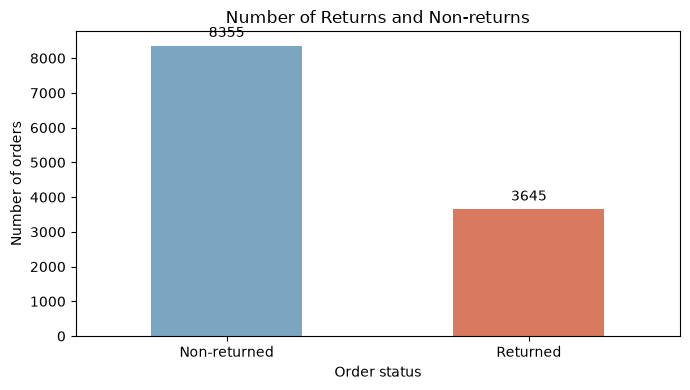

In [4]:
import matplotlib.pyplot as plt

return_counts = df["returned"].value_counts().reindex([0, 1], fill_value=0)
return_counts.index = ["Non-returned", "Returned"]

ax = return_counts.plot(kind="bar", color=["#7aa6c2", "#d9795f"], figsize=(7, 4))
ax.set_title("Number of Returns and Non-returns")
ax.set_xlabel("Order status")
ax.set_ylabel("Number of orders")
ax.tick_params(axis="x", rotation=0)

for bar in ax.patches:
    ax.annotate(
        f"{int(bar.get_height())}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 4),
        textcoords="offset points",
    )

plt.tight_layout()
plt.show()

In [5]:
df.info()




<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  12000 non-null  str    
 1   product_category          12000 non-null  str    
 2   sub_category              12000 non-null  str    
 3   brand                     12000 non-null  str    
 4   product_price             12000 non-null  float64
 5   discount_percent          12000 non-null  float64
 6   product_rating            11760 non-null  float64
 7   review_count              11880 non-null  float64
 8   fragile_item              12000 non-null  int64  
 9   warranty_available        12000 non-null  int64  
 10  product_return_rate       12000 non-null  float64
 11  category_return_rate      12000 non-null  float64
 12  brand_return_rate         12000 non-null  float64
 13  defect_rate               12000 non-null  float64
 14  seller_rating    

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
product_price,12000.0,964.063342,1678.771489,19.510,328.235,597.470,1105.395,64878.670
discount_percent,12000.0,33.567167,19.378304,0.000,16.800,33.500,50.400,67.000
product_rating,11760.0,3.886505,0.635664,1.600,3.500,3.900,4.300,5.000
review_count,11880.0,69.437205,18.446294,24.000,54.000,69.000,85.000,116.000
fragile_item,12000.0,0.197083,0.397812,0.000,0.000,0.000,0.000,1.000
warranty_available,12000.0,0.446500,0.497150,0.000,0.000,0.000,1.000,1.000
product_return_rate,12000.0,0.132522,0.069787,0.001,0.082,0.134,0.183,0.367
category_return_rate,12000.0,0.120377,0.049559,0.001,0.087,0.120,0.154,0.354
brand_return_rate,12000.0,0.131886,0.059397,0.010,0.090,0.135,0.176,0.322
defect_rate,12000.0,0.060629,0.042730,0.000,0.029,0.051,0.082,0.370


<Axes: >

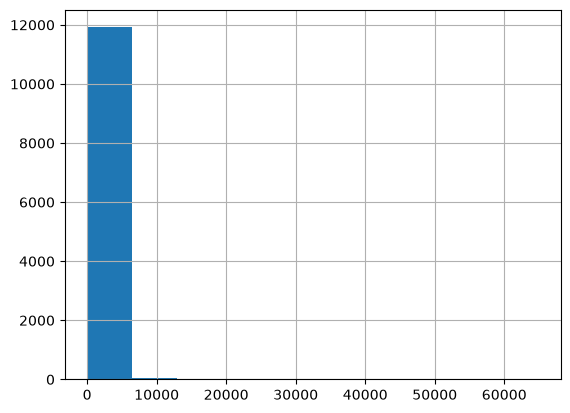

In [7]:
df.product_price.hist()

In [8]:
df.isna().sum()

order_id                      0
product_category              0
sub_category                  0
brand                         0
product_price                 0
discount_percent              0
product_rating              240
review_count                120
fragile_item                  0
warranty_available            0
product_return_rate           0
category_return_rate          0
brand_return_rate             0
defect_rate                   0
seller_rating               180
seller_return_rate            0
fulfillment_type              0
payment_method                0
quantity                      0
shipping_distance_km        120
delayed_delivery              0
wishlist_before_purchase      0
product_page_views            0
customer_support_calls        0
chat_interactions             0
returned                      0
dtype: int64

In [9]:
#catogorical columns
cat_col=["product_category","sub_category","brand","fulfillment_type","payment_method"]

for col in cat_col:
    print(df[col].value_counts())

product_category
Fashion        3413
Electronics    2601
Home           1816
Beauty         1453
Sports         1202
Books           910
Toys            605
Name: count, dtype: int64
sub_category
Mobiles           904
Audio             862
Laptops           835
Women             706
Accessories       684
Footwear          681
Men               673
Kids              669
Furniture         614
Kitchen           614
Decor             588
Haircare          505
Skincare          485
Makeup            463
Team Sports       439
Fitness           389
Outdoor           374
Non-Fiction       335
Fiction           288
Academic          287
Outdoor Play      220
Educational       195
Action Figures    190
Name: count, dtype: int64
brand
Brand_26    442
Brand_21    431
Brand_24    427
Brand_1     425
Brand_15    420
Brand_22    418
Brand_5     418
Brand_11    413
Brand_9     411
Brand_30    410
Brand_7     408
Brand_2     407
Brand_19    406
Brand_14    405
Brand_25    403
Brand_29    400
Brand_4   

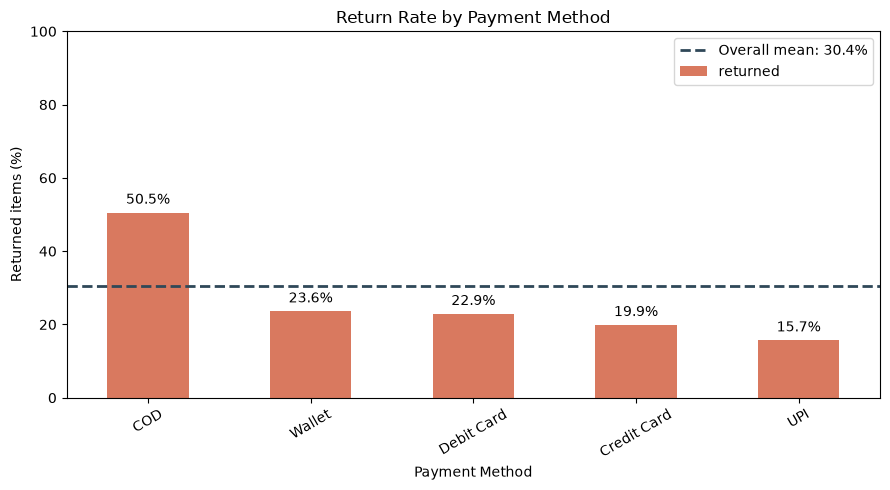

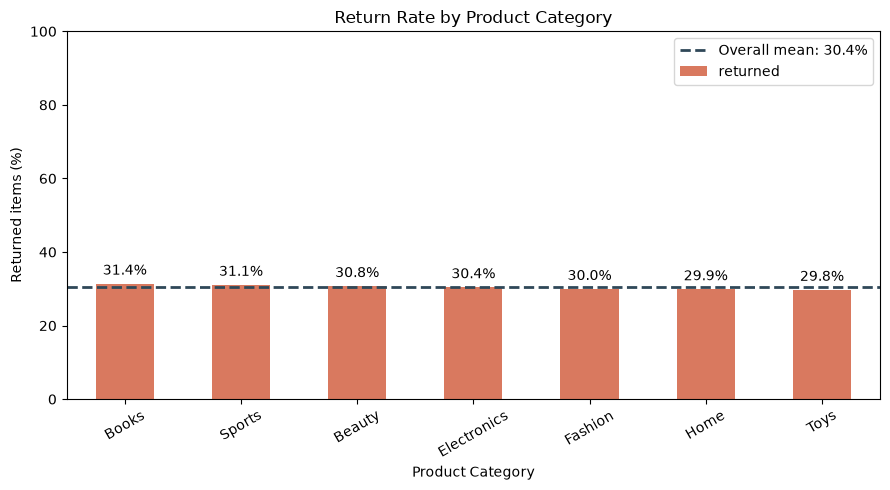

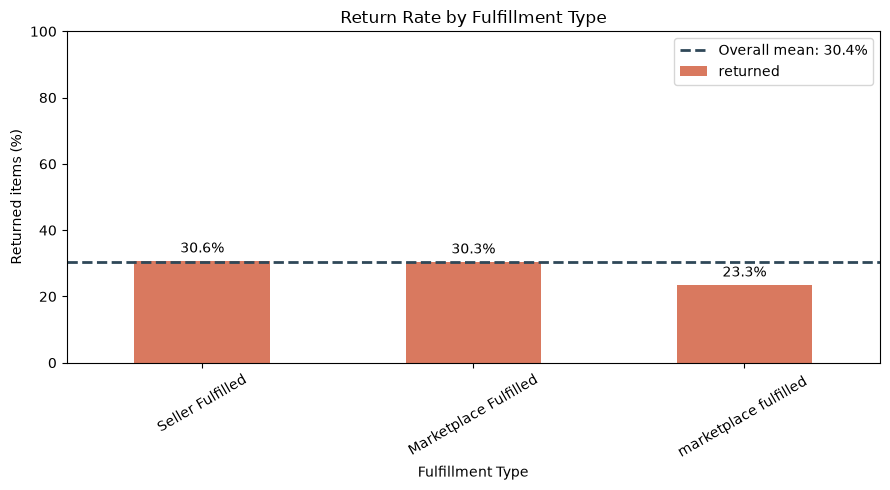

In [11]:
import matplotlib.pyplot as plt

analysis_columns = [
    ("payment_method", "Payment Method"),
    ("product_category", "Product Category"),
    ("fulfillment_type", "Fulfillment Type"),
]

overall_return_rate = df["returned"].mean() * 100

for column, title in analysis_columns:
    return_rates = df.groupby(column)["returned"].mean().mul(100).sort_values(ascending=False)

    ax = return_rates.plot(
        kind="bar",
        figsize=(9, 5),
        color="#d9795f",
    )
    ax.axhline(
        overall_return_rate,
        color="#2f4858",
        linestyle="--",
        linewidth=2,
        label=f"Overall mean: {overall_return_rate:.1f}%",
    )
    ax.set_title(f"Return Rate by {title}")
    ax.set_xlabel(title)
    ax.set_ylabel("Returned items (%)")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=30)
    ax.legend()

    for bar in ax.patches:
        ax.annotate(
            f"{bar.get_height():.1f}%",
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha="center",
            va="bottom",
            xytext=(0, 4),
            textcoords="offset points",
        )

    plt.tight_layout()
    plt.show()

In [12]:
num_col = (
    df.select_dtypes(include="number")
    .columns.drop("returned", errors="ignore")
    .tolist()
)

num_col

['product_price',
 'discount_percent',
 'product_rating',
 'review_count',
 'fragile_item',
 'warranty_available',
 'product_return_rate',
 'category_return_rate',
 'brand_return_rate',
 'defect_rate',
 'seller_rating',
 'seller_return_rate',
 'quantity',
 'shipping_distance_km',
 'delayed_delivery',
 'wishlist_before_purchase',
 'product_page_views',
 'customer_support_calls',
 'chat_interactions']

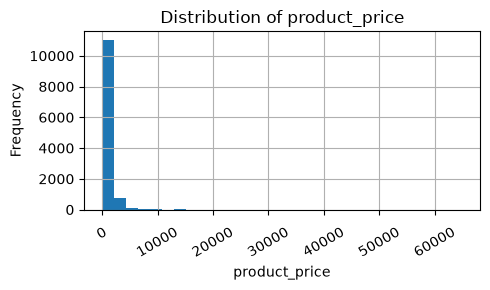

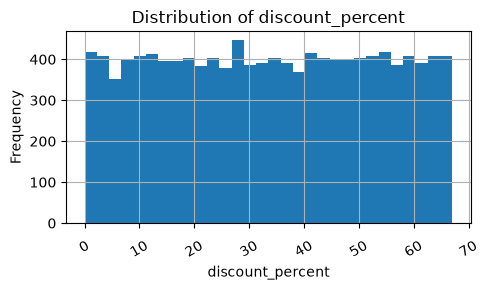

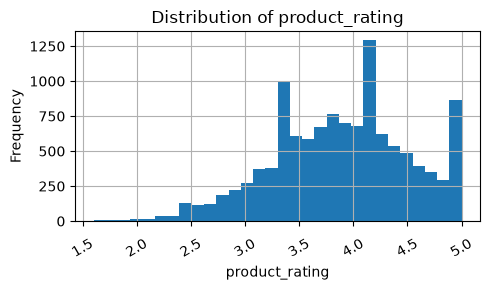

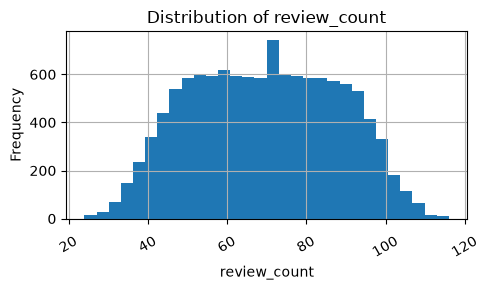

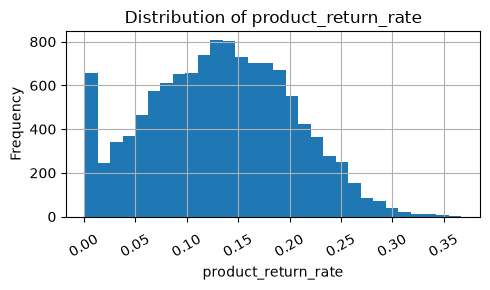

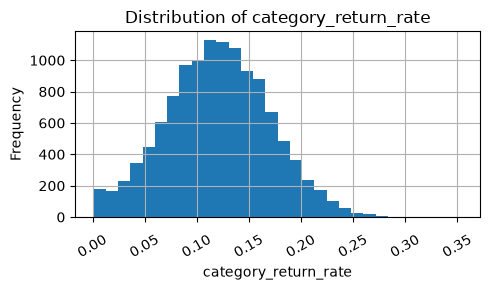

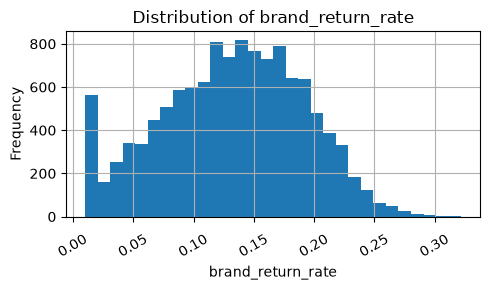

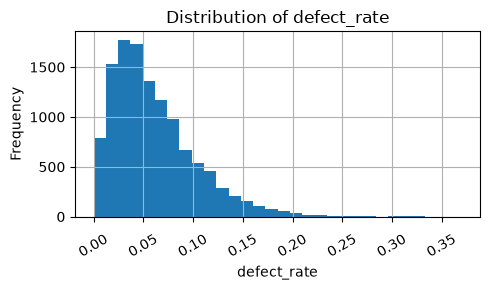

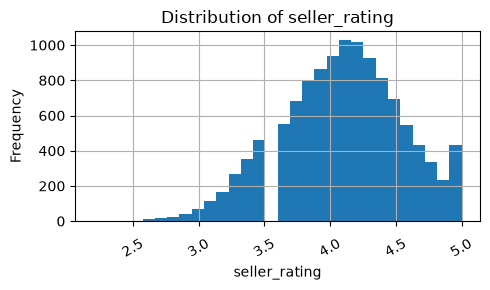

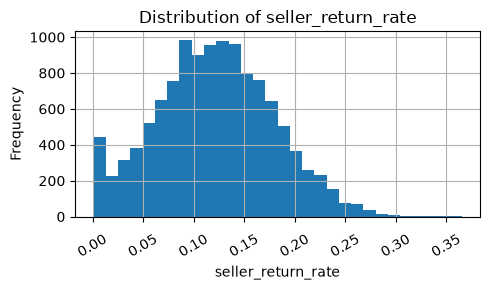

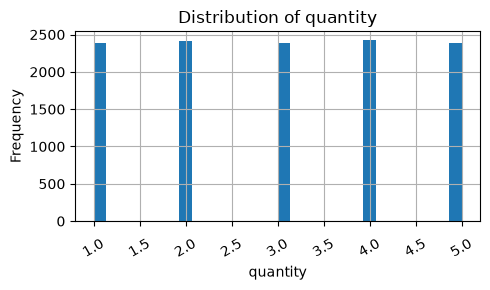

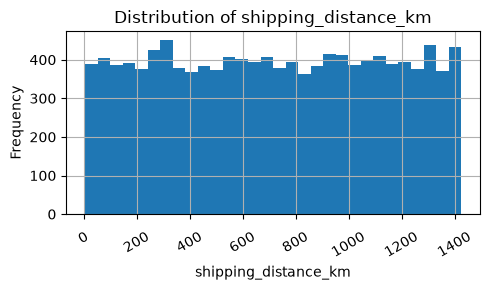

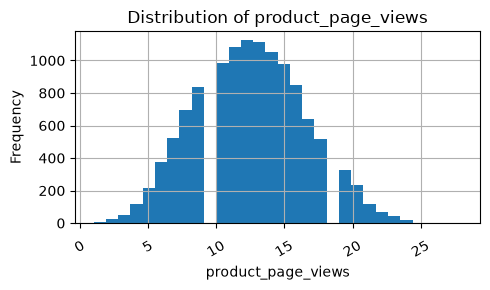

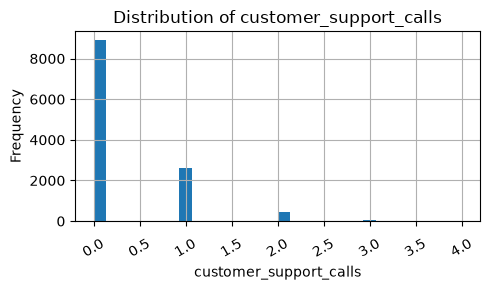

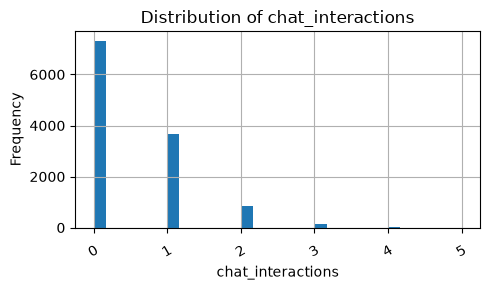

In [13]:
for col in num_col:
    values = df[col].dropna().unique()
    if set(values).issubset({0, 1}):
        continue

    ax = df[col].hist(figsize=(5, 3), bins=30)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.tick_params(axis="x", pad=8, labelrotation=30)
    ax.margins(x=0.05)
    plt.tight_layout()
    plt.show()

Correlation with target
lets say how B changes as A changes

## Why Correlation Is Important

Correlation helps measure the strength and direction of the relationship between numerical variables. In this project, it can show which factors are associated with the `returned` column and may help identify patterns linked to product returns.

- **Positive correlation:** As one variable increases, the other variable tends to increase. For example, a positive correlation with `returned` means higher values of that feature are associated with more returns.
- **Negative correlation:** As one variable increases, the other variable tends to decrease. For example, a negative correlation with `returned` means higher values of that feature are associated with fewer returns.
- **Correlation near zero:** The variables have little or no linear relationship.

Correlation values range from `-1` to `+1`. A value near `+1` indicates a strong positive relationship, while a value near `-1` indicates a strong negative relationship. A value near `0` indicates a weak relationship.

Correlation is useful for selecting features and understanding the dataset, but it does not prove that one variable causes another.

In [14]:
import numpy as np
corr=df.select_dtypes(include=[np.number]).corr()
corr

,product_price,discount_percent,product_rating,review_count,fragile_item,warranty_available,product_return_rate,category_return_rate,brand_return_rate,defect_rate,seller_rating,seller_return_rate,quantity,shipping_distance_km,delayed_delivery,wishlist_before_purchase,product_page_views,customer_support_calls,chat_interactions,returned
product_price,1.000000,-0.016544,-0.009996,0.011318,0.004471,-0.005059,-0.004302,-0.006108,-0.003224,-0.020734,0.008962,0.005713,0.000894,0.002893,0.012480,-0.004764,-0.005788,-0.005461,0.002545,-0.003023
discount_percent,-0.016544,1.000000,0.000143,-0.001287,0.007751,-0.014156,-0.003496,0.018814,0.001693,0.005724,-0.006852,-0.011614,-0.000393,-0.004087,0.005830,-0.005076,-0.000921,0.016842,0.001497,0.009022
product_rating,-0.009996,0.000143,1.000000,-0.004054,-0.009272,-0.013554,-0.006133,0.002965,-0.003017,0.001398,-0.008732,0.007746,-0.009657,-0.000152,0.000457,0.015325,0.016439,0.001983,-0.002238,-0.110463
review_count,0.011318,-0.001287,-0.004054,1.000000,0.004870,0.014399,0.009583,-0.000850,0.009161,0.001629,0.004011,0.002190,-0.006908,0.000360,0.008228,-0.009608,-0.002893,-0.003473,0.006936,0.005825
fragile_item,0.004471,0.007751,-0.009272,0.004870,1.000000,0.018553,-0.005197,0.003906,-0.011399,0.000653,-0.010058,0.004545,-0.008517,0.013720,0.009213,-0.000359,0.000184,-0.002178,0.000701,0.258118
warranty_available,-0.005059,-0.014156,-0.013554,0.014399,0.018553,1.000000,0.014906,-0.004160,0.017477,0.005117,0.008828,-0.005481,-0.005895,-0.005424,-0.013420,0.014134,0.015358,0.011117,-0.000900,-0.213782
product_return_rate,-0.004302,-0.003496,-0.006133,0.009583,-0.005197,0.014906,1.000000,0.004466,0.828173,0.002362,0.012690,0.007550,-0.009250,0.000396,-0.001079,-0.009231,0.012313,0.000120,-0.007042,0.312953
category_return_rate,-0.006108,0.018814,0.002965,-0.000850,0.003906,-0.004160,0.004466,1.000000,0.003246,-0.005091,0.006205,0.015878,-0.007067,-0.016087,-0.014060,0.000243,0.005410,-0.005486,-0.004417,-0.006420
brand_return_rate,-0.003224,0.001693,-0.003017,0.009161,-0.011399,0.017477,0.828173,0.003246,1.000000,-0.010206,0.008259,0.001791,-0.012656,-0.006052,-0.004020,-0.010581,0.008980,0.001996,-0.014422,0.336750
defect_rate,-0.020734,0.005724,0.001398,0.001629,0.000653,0.005117,0.002362,-0.005091,-0.010206,1.000000,-0.000128,0.001354,0.000302,0.014904,0.002763,-0.005108,-0.005438,-0.004293,-0.002231,0.073658


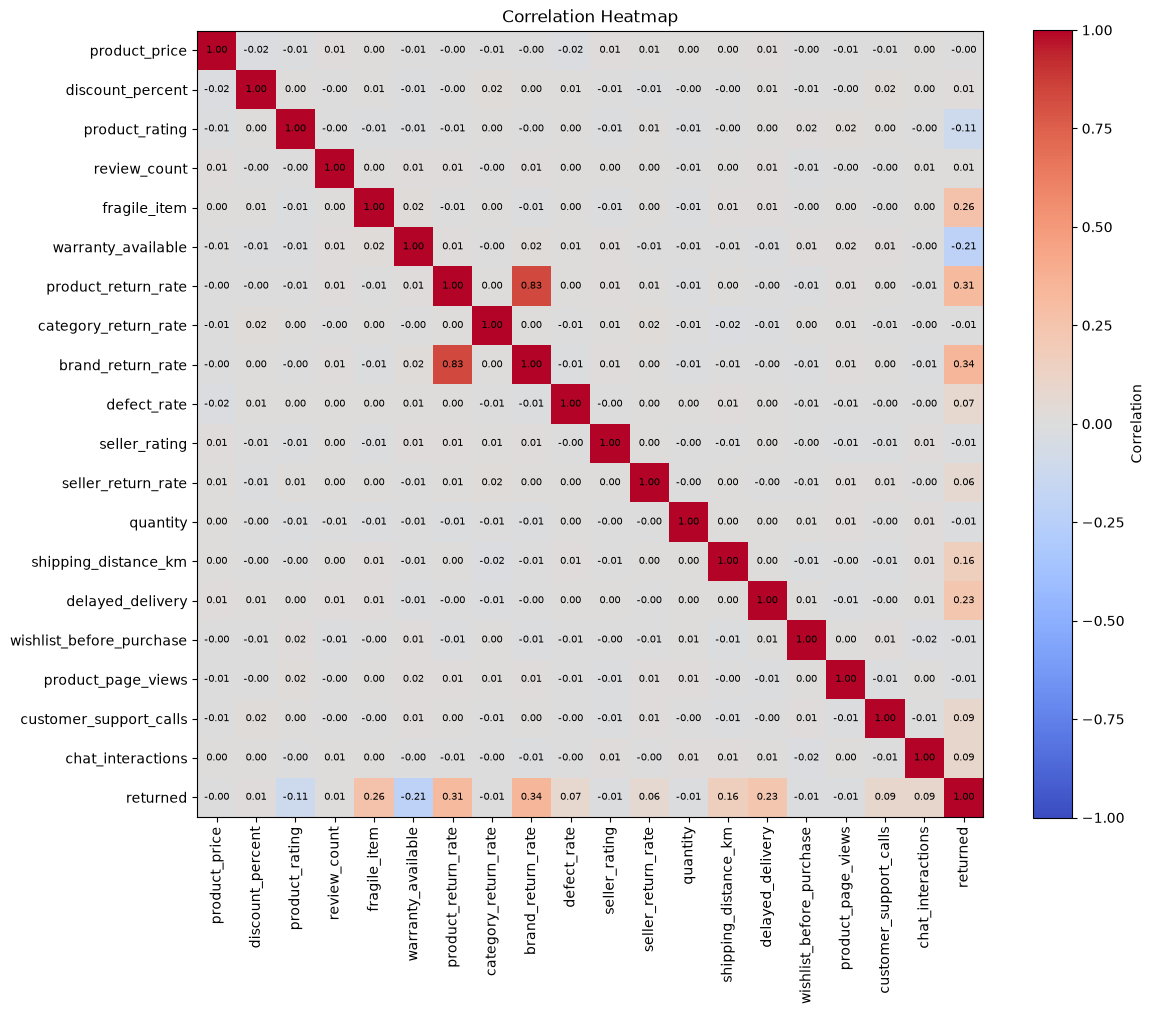

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))
image = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.index)
ax.set_title("Correlation Heatmap")

for row in range(corr.shape[0]):
    for column in range(corr.shape[1]):
        ax.text(
            column,
            row,
            f"{corr.iloc[row, column]:.2f}",
            ha="center",
            va="center",
            fontsize=7,
        )

fig.colorbar(image, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

In [16]:
df.fulfillment_type.value_counts()

fulfillment_type
Marketplace Fulfilled     7193
Seller Fulfilled          4747
marketplace fulfilled       60
Name: count, dtype: int64

In [17]:
df_clean = df.copy()

df_clean["fulfillment_type"] = (
    df_clean["fulfillment_type"]
    .str.strip()
    .str.replace("_", " ", regex=False)
    .str.title()
)

df_clean["fulfillment_type"].value_counts()

fulfillment_type
Marketplace Fulfilled    7253
Seller Fulfilled         4747
Name: count, dtype: int64

In [18]:
df_clean.head(2)

,order_id,product_category,sub_category,brand,product_price,discount_percent,product_rating,review_count,fragile_item,warranty_available,product_return_rate,category_return_rate,brand_return_rate,defect_rate,seller_rating,seller_return_rate,fulfillment_type,payment_method,quantity,shipping_distance_km,delayed_delivery,wishlist_before_purchase,product_page_views,customer_support_calls,chat_interactions,returned
0,ORD100000,Beauty,Haircare,Brand_23,844.1,65.2,2.1,96.0,1,1,0.172,0.173,0.219,0.116,4.1,0.128,Marketplace Fulfilled,Credit Card,5,187.9,0,0,9,0,0,1
1,ORD100001,Toys,Educational,Brand_9,559.9,30.1,4.1,87.0,0,1,0.168,0.125,0.155,0.031,4.2,0.171,Marketplace Fulfilled,Credit Card,2,1281.9,0,0,14,0,2,0


In [19]:
df_clean=df_clean.drop(columns=['order_id'])


In [20]:
df_clean=df_clean.drop_duplicates()

In [21]:
df_clean.shape

(12000, 25)

## Feature Engineering

Feature engineering is the process of creating, transforming, and selecting input variables so that a machine-learning model can identify useful patterns more easily. Good features should represent meaningful information, use consistent formats, and be created without using information that would only be available after the prediction is made.

### 1. Identify the Target and Predictors

The target column in this project is `returned`. It indicates whether an order was returned, usually with `0` for not returned and `1` for returned. All other columns are potential predictor features, although identifiers and columns that reveal the outcome should be excluded.

- **Target:** `returned`
- **Categorical features:** `product_category`, `sub_category`, `brand`, `fulfillment_type`, and `payment_method`
- **Numerical features:** price, ratings, counts, rates, quantities, distances, views, calls, and other measurements
- **Identifier:** `order_id`, which should not be used as a predictor because it identifies a row rather than describing customer or product behavior

### 2. Clean Features Before Creating New Ones

Feature engineering should be performed after basic data cleaning. Text categories should be stripped of extra spaces and standardized, missing values should be handled consistently, and numeric columns should contain valid numeric values.

```python
# Example category cleaning
for column in categorical_columns:
    df_clean[column] = (
        df_clean[column]
        .astype("string")
        .str.strip()
        .str.replace("_", " ", regex=False)
        .str.title()
    )
```

### 3. Numerical Transformations: When to Use What

Different transformations solve different data problems. Inspect a histogram, summary statistics, and the minimum and maximum values before choosing one.

#### Log Transformation

Use a log transformation when a numerical feature is strongly right-skewed: most observations are small, but a few observations are extremely large. It compresses large values and makes the distribution less affected by outliers.

Good candidates in this dataset include `review_count`, `product_page_views`, `customer_support_calls`, and `chat_interactions`.

Use `np.log1p(x)` when values include zero because it calculates $\log(1+x)$ safely. Do not use a basic log transformation when zero or negative values are possible.

```python
import numpy as np

df_clean["log_review_count"] = np.log1p(df_clean["review_count"])
df_clean["log_product_page_views"] = np.log1p(df_clean["product_page_views"])
```

#### Square-Root Transformation

Use a square-root transformation for moderately right-skewed non-negative count data when a log transformation would be too strong. It is useful for counts such as `review_count` or `customer_support_calls` with a smaller range of values.

```python
df_clean["sqrt_review_count"] = np.sqrt(df_clean["review_count"])
```

#### Standardization

Use standardization when a model depends on distances, slopes, or feature magnitude. It changes a feature to approximately mean `0` and standard deviation `1`.

Use it for logistic regression, support vector machines, k-nearest neighbors, principal component analysis, and neural networks. It is usually unnecessary for decision trees, random forests, and gradient-boosted tree models.

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clean[numerical_columns])
```

Fit the scaler on training data only, then use that fitted scaler on validation and test data.

#### Min-Max Scaling

Use min-max scaling when a model works best with features in a fixed range, commonly `0` to `1`. It is useful for neural networks and some distance-based methods.

Avoid relying on it when strong outliers are present because the largest and smallest values determine the range and can compress most observations into a small interval.

```python
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_clean[numerical_columns])
```

#### Robust Scaling

Use robust scaling when a feature contains substantial outliers. It uses the median and interquartile range instead of the mean and standard deviation, so extreme values have less influence.

It can be appropriate for `product_price`, `shipping_distance_km`, `review_count`, or `product_page_views` when their distributions contain extreme observations.

```python
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df_scaled = scaler.fit_transform(df_clean[numerical_columns])
```

#### Binning or Bucketing

Use binning when ranges have a meaningful interpretation or when the relationship with returns is not linear. For example, product prices could be grouped into low, medium, and high price bands.

Binning improves interpretability but loses detail. Do not use it automatically when the exact numerical value is important.

```python
df_clean["price_band"] = pd.cut(
    df_clean["product_price"],
    bins=[0, 25, 100, np.inf],
    labels=["Low", "Medium", "High"],
)
```

#### Ratios and Percentages

Use ratios when the relationship between two measurements is more meaningful than either measurement alone. Always protect against division by zero.

```python
df_clean["support_calls_per_view"] = (
    df_clean["customer_support_calls"]
    / df_clean["product_page_views"].replace(0, np.nan)
)
```

#### Differences

Use differences when comparing two measurements on the same or a similar scale. For example, the difference between product and seller ratings may identify mismatched expectations.

```python
df_clean["rating_difference"] = (
    df_clean["product_rating"] - df_clean["seller_rating"]
)
```

### 4. Create Useful Numerical Features

Numerical columns can be transformed into features that better describe customer behavior or product performance.

```python
df_clean["discount_amount"] = (
    df_clean["product_price"] * df_clean["discount_percent"] / 100
)
df_clean["price_after_discount"] = (
    df_clean["product_price"] - df_clean["discount_amount"]
)
df_clean["customer_contact_total"] = (
    df_clean["customer_support_calls"] + df_clean["chat_interactions"]
)
```

### 5. Encode Categorical Features: When to Use What

Machine-learning models generally require numeric input.

- **One-hot encoding:** Use for low- or medium-cardinality nominal categories such as `payment_method` and `fulfillment_type`. It does not imply an order between categories.
- **Ordinal encoding:** Use only when categories have a real order, such as low, medium, and high. Do not use it for unrelated payment methods because the assigned numbers would be misleading.
- **Frequency encoding:** Use for high-cardinality columns such as `brand` when a category's frequency may contain useful information.
- **Target encoding:** Use when there are many categories and category-level return behavior is important. Fit it on training data only, preferably with cross-validation, to prevent leakage.

```python
df_model = pd.get_dummies(
    df_clean,
    columns=["product_category", "fulfillment_type", "payment_method"],
    drop_first=True,
    dtype=int,
)
```

### 6. Create Interaction Features Carefully

Use an interaction feature when the effect of one variable may depend on another. For example, return behavior might depend on both product price and discount percentage.

```python
df_clean["price_discount_interaction"] = (
    df_clean["product_price"] * df_clean["discount_percent"]
)
```

Interaction features should have a clear business interpretation. Creating too many arbitrary combinations can increase noise and overfitting.

### 7. Avoid Target Leakage

Target leakage occurs when a feature contains information about the target that would not be available when making a real prediction. Leakage can produce excellent training results but poor performance on new data.

Potential risks in this dataset include:

- `product_return_rate`, `category_return_rate`, and `brand_return_rate` may be calculated using the same rows as the target.
- Any feature created after the product was returned should be excluded.
- Target or mean encoding must be fitted using training data only.
- Group-level return rates should use out-of-fold or historical calculations for a realistic model.

A useful question is: **Would this value be known at the exact moment the return prediction is made?** If not, the feature should not be used.

### 8. Select Relevant Features

Feature selection reduces noise, improves interpretability, and can reduce training time. Useful checks include:

- Remove identifier columns such as `order_id`.
- Remove duplicate or constant columns.
- Inspect correlation with `returned` for numerical features.
- Compare return rates across categorical groups.
- Check highly correlated predictors and retain the more meaningful feature.
- Use model-based importance only after creating a proper train-test split.

Correlation is useful for identifying linear relationships, but a low correlation does not always mean a feature is useless. A feature may have a non-linear relationship or may become useful when combined with another feature.

### 9. Validate the Engineered Dataset

After creating features, confirm that the data is ready for modeling:

```python
feature_columns = [column for column in df_model.columns if column != "returned"]

print("Feature count:", len(feature_columns))
print("Missing values:")
print(df_model[feature_columns].isna().sum().sum())
print("Duplicate rows:", df_model.duplicated().sum())
```

Check that all model features are numeric, missing values are handled, values are finite, and the target remains separate from the predictors.

### 10. Recommended Workflow

1. Split the data into training and testing sets.
2. Fit cleaning and feature-engineering transformations on the training set.
3. Apply the same transformations to the test set.
4. Train the model using the engineered training features.
5. Evaluate on untouched test data using appropriate classification metrics.
6. Review feature importance and remove features that are leaked, unstable, or not useful.

Feature engineering should improve the representation of the data, not simply add more columns. Every engineered feature should have a clear purpose and should be validated against the project goal.

In [22]:
df_clean.head(2)

,product_category,sub_category,brand,product_price,discount_percent,product_rating,review_count,fragile_item,warranty_available,product_return_rate,category_return_rate,brand_return_rate,defect_rate,seller_rating,seller_return_rate,fulfillment_type,payment_method,quantity,shipping_distance_km,delayed_delivery,wishlist_before_purchase,product_page_views,customer_support_calls,chat_interactions,returned
0,Beauty,Haircare,Brand_23,844.1,65.2,2.1,96.0,1,1,0.172,0.173,0.219,0.116,4.1,0.128,Marketplace Fulfilled,Credit Card,5,187.9,0,0,9,0,0,1
1,Toys,Educational,Brand_9,559.9,30.1,4.1,87.0,0,1,0.168,0.125,0.155,0.031,4.2,0.171,Marketplace Fulfilled,Credit Card,2,1281.9,0,0,14,0,2,0


<Axes: >

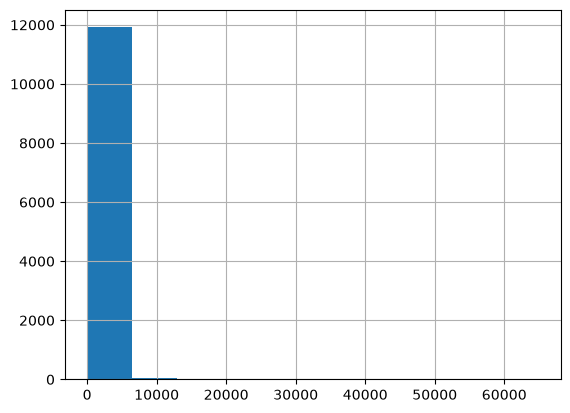

In [23]:
df.product_price.hist()

In [24]:
def add_f(d):
    d['total_support_contacts']=d['customer_support_calls']+d['chat_interactions']
    d['log_price']=np.log1p(d['product_price'])
    d=d.drop(columns=['product_price','customer_support_calls','chat_interactions'])
    return d
df_feat=add_f(df_clean)
df_feat.head(3)

,product_category,sub_category,brand,discount_percent,product_rating,review_count,fragile_item,warranty_available,product_return_rate,category_return_rate,brand_return_rate,defect_rate,seller_rating,seller_return_rate,fulfillment_type,payment_method,quantity,shipping_distance_km,delayed_delivery,wishlist_before_purchase,product_page_views,returned,total_support_contacts,log_price
0,Beauty,Haircare,Brand_23,65.2,2.1,96.0,1,1,0.172,0.173,0.219,0.116,4.1,0.128,Marketplace Fulfilled,Credit Card,5,187.9,0,0,9,1,0,6.739455
1,Toys,Educational,Brand_9,30.1,4.1,87.0,0,1,0.168,0.125,0.155,0.031,4.2,0.171,Marketplace Fulfilled,Credit Card,2,1281.9,0,0,14,0,2,6.329543
2,Electronics,Laptops,Brand_21,53.4,3.0,75.0,0,0,0.045,0.125,0.103,0.057,4.1,0.186,Marketplace Fulfilled,UPI,3,575.2,1,0,7,0,0,7.367033


In [25]:
from sklearn.model_selection import train_test_split

X_feat = df_feat.drop(columns=["returned"])
y_feat = df_feat["returned"]

X_feat_train, X_feat_test, y_feat_train, y_feat_test = train_test_split(
    X_feat,
    y_feat,
    test_size=0.20,
    random_state=42,
    stratify=y_feat,
 )

print("Training features:", X_feat_train.shape)
print("Testing features:", X_feat_test.shape)
print("Training target distribution:")
print(y_feat_train.value_counts(normalize=True).sort_index())
print("Testing target distribution:")
print(y_feat_test.value_counts(normalize=True).sort_index())
X_feat_train.shape

Training features: (9600, 23)
Testing features: (2400, 23)
Training target distribution:
returned
0    0.69625
1    0.30375
Name: proportion, dtype: float64
Testing target distribution:
returned
0    0.69625
1    0.30375
Name: proportion, dtype: float64


(9600, 23)

<Axes: >

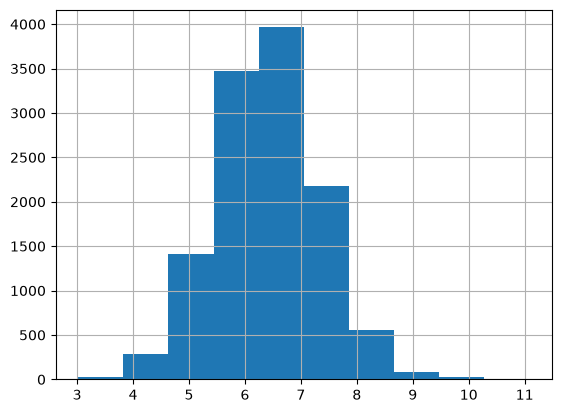

In [26]:
df_feat.log_price.hist()

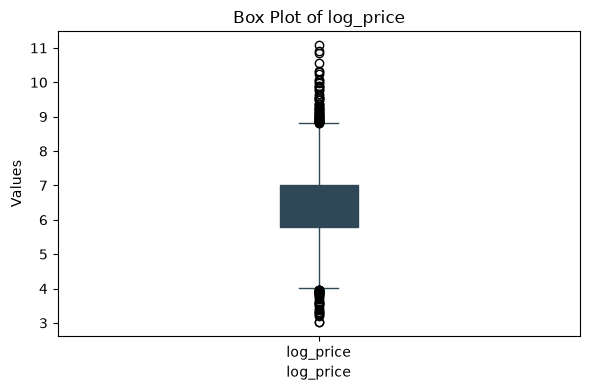

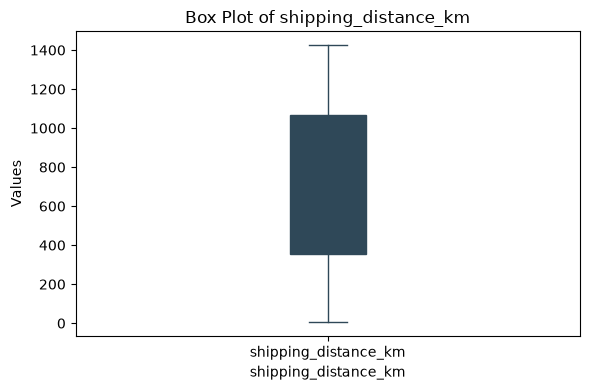

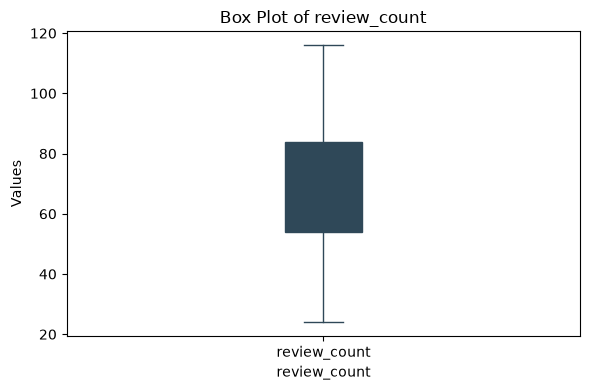

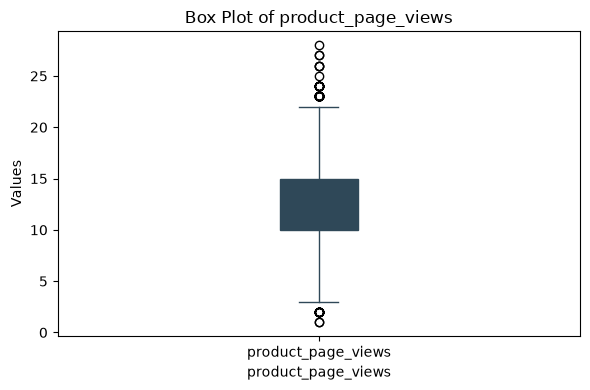

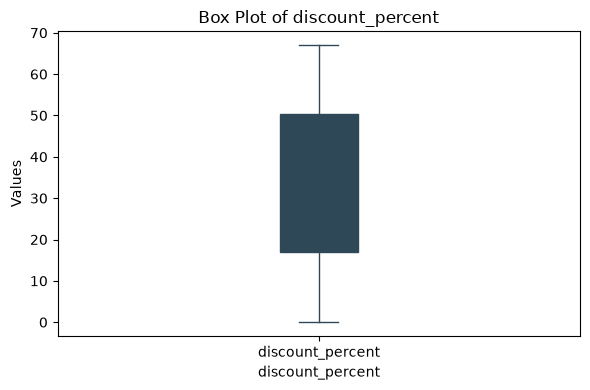

In [27]:
boxplot_columns = [
    "log_price",
    "shipping_distance_km",
    "review_count",
    "product_page_views",
    "discount_percent",
]



for column in boxplot_columns:
    fig, ax = plt.subplots(figsize=(6, 4))
    X_feat_train[[column]].plot(
        kind="box",
        ax=ax,
        patch_artist=True,
        color="#2f4858",
    )
    ax.set_title(f"Box Plot of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Values")
   
    plt.tight_layout()
    plt.show()

In [28]:
# Remove extreme outliers (Q3 + 3*IQR) on log_price - training set only.
# NOTE: with product_price already log-transformed, the tail is tamed, so this now removes
# very few rows. review_count / product_page_views are near-symmetric and bounded, so IQR
# outlier removal on them is not warranted (it would just clip legitimate values). We keep
# the step on log_price alone as a light, defensible guard against any residual extremes.
outlier_cols = ["log_price"]
mask = pd.Series(True, index=X_feat_train.index)
for c in outlier_cols:
    q1, q3 = X_feat_train[c].quantile(0.25), X_feat_train[c].quantile(0.75)
    upper = q3 + 3 * (q3 - q1)
    mask &= X_feat_train[c] <= upper
removed = (~mask).sum()
X_feat_train, y_feat_train = X_feat_train[mask], y_feat_train[mask]
print(f"Removed {removed} extreme-outlier rows from training set. New train shape: {X_feat_train.shape}")

Removed 3 extreme-outlier rows from training set. New train shape: (9597, 23)


In [30]:
X_feat_train.head(3)

,product_category,sub_category,brand,discount_percent,product_rating,review_count,fragile_item,warranty_available,product_return_rate,category_return_rate,brand_return_rate,defect_rate,seller_rating,seller_return_rate,fulfillment_type,payment_method,quantity,shipping_distance_km,delayed_delivery,wishlist_before_purchase,product_page_views,total_support_contacts,log_price
6601,Fashion,Accessories,Brand_23,28.0,4.2,53.0,0,1,0.224,0.155,0.220,0.060,4.1,0.180,Marketplace Fulfilled,Wallet,5,910.0,0,1,13,0,5.726978
9297,Fashion,Accessories,Brand_18,13.7,2.9,34.0,0,0,0.071,0.089,0.112,0.016,3.0,0.001,Marketplace Fulfilled,Wallet,3,469.4,0,0,14,0,6.013960
6057,Fashion,Accessories,Brand_22,16.3,4.2,47.0,0,1,0.001,0.120,0.046,0.022,4.5,0.163,Marketplace Fulfilled,UPI,1,120.1,0,1,14,0,6.504243


In [31]:
binary_cols=['fragile_item','warranty_available','delayed_delivery','wishlist_before_purchase']
cat_cols=['fulfillment_type','payment_method','brand','sub_category','product_category']
num_fea=[c for c in X_feat_train.columns if c not  in binary_cols +cat_cols]
all_num_cols=num_fea+binary_cols

trian_median=X_feat_train[num_fea].median().to_dict()
train_mode=X_feat_train[binary_cols].mode().to_dict()
print(trian_median)
print(train_mode)

{'discount_percent': 33.5, 'product_rating': 3.9, 'review_count': 69.0, 'product_return_rate': 0.134, 'category_return_rate': 0.12, 'brand_return_rate': 0.136, 'defect_rate': 0.051, 'seller_rating': 4.1, 'seller_return_rate': 0.121, 'quantity': 3.0, 'shipping_distance_km': 714.1, 'product_page_views': 12.0, 'total_support_contacts': 1.0, 'log_price': 6.389636457722005}
{'fragile_item': {0: 0}, 'warranty_available': {0: 0}, 'delayed_delivery': {0: 0}, 'wishlist_before_purchase': {0: 0}}


In [32]:
X_feat.isna().sum()

product_category              0
sub_category                  0
brand                         0
discount_percent              0
product_rating              240
review_count                120
fragile_item                  0
warranty_available            0
product_return_rate           0
category_return_rate          0
brand_return_rate             0
defect_rate                   0
seller_rating               180
seller_return_rate            0
fulfillment_type              0
payment_method                0
quantity                      0
shipping_distance_km        120
delayed_delivery              0
wishlist_before_purchase      0
product_page_views            0
total_support_contacts        0
log_price                     0
dtype: int64

In [33]:
X_feat_train[num_fea]=X_feat_train[num_fea].fillna(trian_median)
X_feat_test[num_fea]=X_feat_test[num_fea].fillna(trian_median)

X_feat_train.isna().sum()

product_category            0
sub_category                0
brand                       0
discount_percent            0
product_rating              0
review_count                0
fragile_item                0
warranty_available          0
product_return_rate         0
category_return_rate        0
brand_return_rate           0
defect_rate                 0
seller_rating               0
seller_return_rate          0
fulfillment_type            0
payment_method              0
quantity                    0
shipping_distance_km        0
delayed_delivery            0
wishlist_before_purchase    0
product_page_views          0
total_support_contacts      0
log_price                   0
dtype: int64

In [34]:
X_feat_train.head(3)

,product_category,sub_category,brand,discount_percent,product_rating,review_count,fragile_item,warranty_available,product_return_rate,category_return_rate,brand_return_rate,defect_rate,seller_rating,seller_return_rate,fulfillment_type,payment_method,quantity,shipping_distance_km,delayed_delivery,wishlist_before_purchase,product_page_views,total_support_contacts,log_price
6601,Fashion,Accessories,Brand_23,28.0,4.2,53.0,0,1,0.224,0.155,0.220,0.060,4.1,0.180,Marketplace Fulfilled,Wallet,5,910.0,0,1,13,0,5.726978
9297,Fashion,Accessories,Brand_18,13.7,2.9,34.0,0,0,0.071,0.089,0.112,0.016,3.0,0.001,Marketplace Fulfilled,Wallet,3,469.4,0,0,14,0,6.013960
6057,Fashion,Accessories,Brand_22,16.3,4.2,47.0,0,1,0.001,0.120,0.046,0.022,4.5,0.163,Marketplace Fulfilled,UPI,1,120.1,0,1,14,0,6.504243


In [35]:
from sklearn.preprocessing import StandardScaler


scaler=StandardScaler()
X_feat_train[num_fea]=scaler.fit_transform(X_feat_train[num_fea])
X_feat_test[num_fea]=scaler.transform(X_feat_test[num_fea])

X_feat_test.head(3)

,product_category,sub_category,brand,discount_percent,product_rating,review_count,fragile_item,warranty_available,product_return_rate,category_return_rate,brand_return_rate,defect_rate,seller_rating,seller_return_rate,fulfillment_type,payment_method,quantity,shipping_distance_km,delayed_delivery,wishlist_before_purchase,product_page_views,total_support_contacts,log_price
1650,Beauty,Skincare,Brand_5,-1.426766,-0.607676,-2.301822,0,0,-1.530121,1.308305,-2.050281,-0.757612,-0.417139,0.738806,Marketplace Fulfilled,COD,1.413045,0.870414,0,1,-2.387657,0.222819,-0.165382
5799,Sports,Outdoor,Brand_4,0.593378,1.774557,-0.995685,0,0,1.647611,-0.534459,1.204090,0.515539,1.309811,-0.495492,Seller Fulfilled,Debit Card,-0.712281,0.952128,0,1,-0.128206,0.222819,-1.116685
4756,Electronics,Audio,Brand_29,-1.137436,1.298111,-1.050108,0,0,-0.442249,-0.372458,-0.020493,-1.181996,-0.417139,0.790235,Marketplace Fulfilled,COD,-0.712281,0.739769,0,0,0.875994,0.222819,0.145882


In [36]:
X_feat_test=pd.get_dummies(X_feat_test, columns=cat_cols, dtype=int)
X_feat_train=pd.get_dummies(X_feat_train, columns=cat_cols, dtype=int)

X_feat_test.head(3)

,discount_percent,product_rating,review_count,fragile_item,warranty_available,product_return_rate,category_return_rate,brand_return_rate,defect_rate,seller_rating,seller_return_rate,quantity,shipping_distance_km,delayed_delivery,wishlist_before_purchase,product_page_views,total_support_contacts,log_price,fulfillment_type_Marketplace Fulfilled,fulfillment_type_Seller Fulfilled,payment_method_COD,payment_method_Credit Card,payment_method_Debit Card,payment_method_UPI,payment_method_Wallet,brand_Brand_1,brand_Brand_10,brand_Brand_11,brand_Brand_12,brand_Brand_13,brand_Brand_14,brand_Brand_15,brand_Brand_16,brand_Brand_17,brand_Brand_18,brand_Brand_19,brand_Brand_2,brand_Brand_20,brand_Brand_21,brand_Brand_22,brand_Brand_23,brand_Brand_24,brand_Brand_25,brand_Brand_26,brand_Brand_27,brand_Brand_28,brand_Brand_29,brand_Brand_3,brand_Brand_30,brand_Brand_4,brand_Brand_5,brand_Brand_6,brand_Brand_7,brand_Brand_8,brand_Brand_9,sub_category_Academic,sub_category_Accessories,sub_category_Action Figures,sub_category_Audio,sub_category_Decor,sub_category_Educational,sub_category_Fiction,sub_category_Fitness,sub_category_Footwear,sub_category_Furniture,sub_category_Haircare,sub_category_Kids,sub_category_Kitchen,sub_category_Laptops,sub_category_Makeup,sub_category_Men,sub_category_Mobiles,sub_category_Non-Fiction,sub_category_Outdoor,sub_category_Outdoor Play,sub_category_Skincare,sub_category_Team Sports,sub_category_Women,product_category_Beauty,product_category_Books,product_category_Electronics,product_category_Fashion,product_category_Home,product_category_Sports,product_category_Toys
1650,-1.426766,-0.607676,-2.301822,0,0,-1.530121,1.308305,-2.050281,-0.757612,-0.417139,0.738806,1.413045,0.870414,0,1,-2.387657,0.222819,-0.165382,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0
5799,0.593378,1.774557,-0.995685,0,0,1.647611,-0.534459,1.204090,0.515539,1.309811,-0.495492,-0.712281,0.952128,0,1,-0.128206,0.222819,-1.116685,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
4756,-1.137436,1.298111,-1.050108,0,0,-0.442249,-0.372458,-0.020493,-1.181996,-0.417139,0.790235,-0.712281,0.739769,0,0,0.875994,0.222819,0.145882,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

models={
    "Logistic Regrssion": LogisticRegression(max_iter=1000,class_weight="balanced",random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced",random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300,class_weight="balanced",n_jobs=1,random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=5,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric="logloss", random_state=42, n_jobs=-1)
}

In [38]:
fitted={}

for name,est in models.items():
    est.fit(X_feat_train,y_feat_train)
    fitted[name]=est
    print("trained : ",name)
print(fitted.items())

trained :  Logistic Regrssion
trained :  Decision Tree
trained :  Random Forest
trained :  XGBoost
dict_items([('Logistic Regrssion', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)), ('Decision Tree', DecisionTreeClassifier(class_weight='balanced', random_state=42)), ('Random Forest', RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=1,
                       random_state=42)), ('XGBoost', XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=Non

In [39]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


def eval_module(model,X,y):
    pred=model.predict(X)
    return{
        "Accuracy : " : accuracy_score(y,pred),
        "Precision : " : precision_score(y,pred,zero_division=0),
        "Recall : " : recall_score(y,pred,zero_division=0),
        "f1" : f1_score(y,pred,zero_division=0),
    }
comparison=pd.DataFrame({n: eval_module(m,X_feat_test,y_feat_test)for n,m in fitted.items()})

comparison.round(4)

,Logistic Regrssion,Decision Tree,Random Forest,XGBoost
Accuracy :,0.8558,0.7800,0.8458,0.8612
Precision :,0.7194,0.6360,0.7462,0.7946
Recall :,0.8615,0.6447,0.7462,0.7325
f1,0.7840,0.6403,0.7462,0.7623


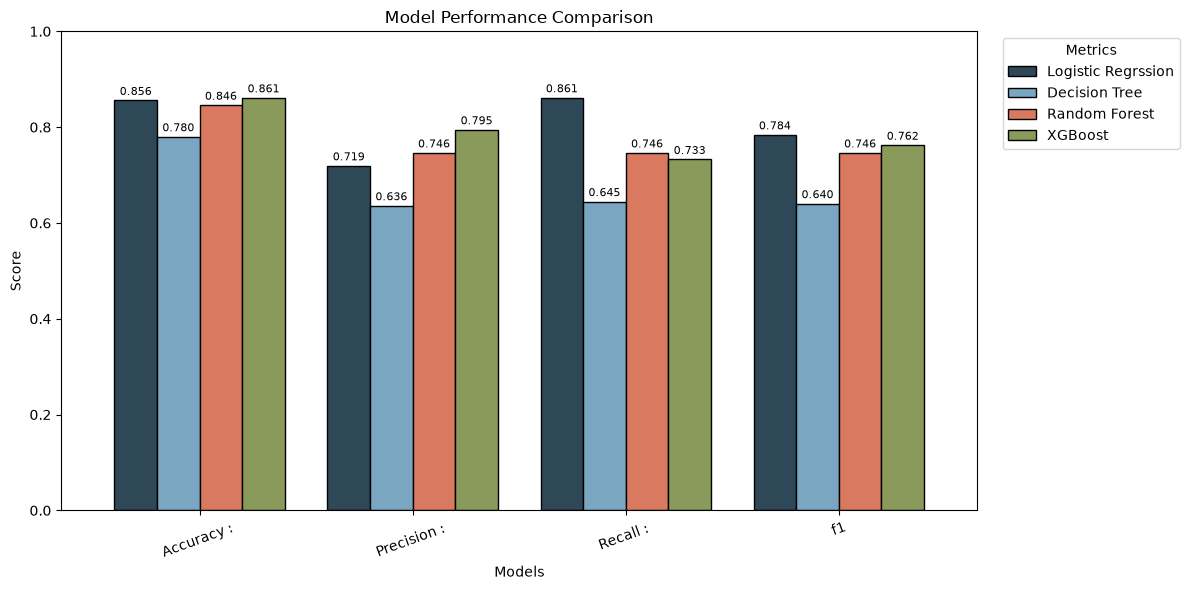

In [40]:
import matplotlib.pyplot as plt

ax = comparison.plot(
    kind="bar",
    figsize=(12, 6),
    color=["#2f4858", "#7aa6c2", "#d9795f", "#8a9a5b"],
    edgecolor="black",
    width=0.8,
 )

ax.set_title("Model Performance Comparison")
ax.set_xlabel("Models")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Metrics", bbox_to_anchor=(1.02, 1), loc="upper left")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2, fontsize=8)

plt.tight_layout()
plt.show()

In [41]:
final_model=fitted["Logistic Regrssion"]
tuned_met=eval_module(final_model,X_feat_test,y_feat_test)
print(f"finale metrics using test data")

for k,v in tuned_met.items():
    print(f"{k:10s}: {v:.4f}")


finale metrics using test data
Accuracy : : 0.8558
Precision : : 0.7194
Recall :  : 0.8615
f1        : 0.7840


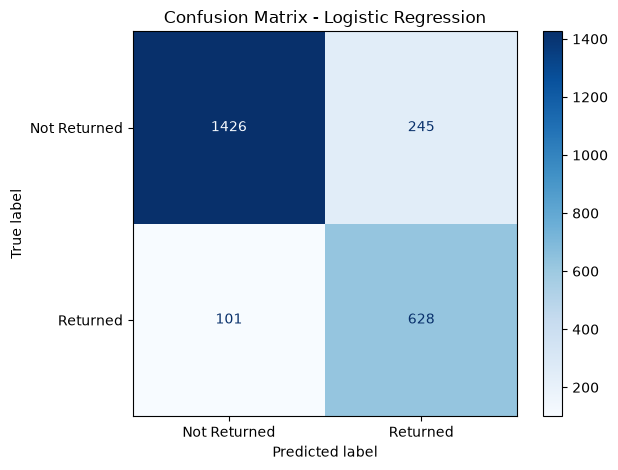

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_pred = final_model.predict(X_feat_test)
cm = confusion_matrix(y_feat_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Returned", "Returned"],
 )
display.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

In [4]:
# Production model packaging
# The API uses this persisted scikit-learn Pipeline:
# 1. Clean and validate the source data.
# 2. Add total_support_contacts and log_price.
# 3. Impute numeric values with training medians and standardize them.
# 4. Impute categorical values and one-hot encode them.
# 5. Predict returned with balanced LogisticRegression.
# The pipeline stores preprocessing and the fitted model together in one joblib file.

import importlib
import sys
from pathlib import Path

import joblib
import pandas as pd

PROJECT_ROOT = Path.cwd()
src_path = PROJECT_ROOT / "src"
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import returns_app.model as model

model = importlib.reload(model)
FEATURE_COLUMNS = model.FEATURE_COLUMNS
build_pipeline = model.build_pipeline
clean_data = model.clean_data

DATA_PATH = PROJECT_ROOT / "returns_dataset.csv"
ARTIFACT_PATH = PROJECT_ROOT / "artifacts/return_model.joblib"

training_data = clean_data(pd.read_csv(DATA_PATH), training=True)
X = training_data[FEATURE_COLUMNS]
y = training_data["returned"].astype(int)

production_pipeline = build_pipeline()
production_pipeline.fit(X, y)

ARTIFACT_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(production_pipeline, ARTIFACT_PATH)

print(f"Saved model artifact: {ARTIFACT_PATH}")
print(f"Training rows after cleaning: {len(training_data)}")
print(f"Input features: {len(FEATURE_COLUMNS)}")
print("Model: balanced LogisticRegression")

Saved model artifact: c:\Users\Saketh\ml\project\artifacts\return_model.joblib
Training rows after cleaning: 12000
Input features: 24
Model: balanced LogisticRegression
